In [1]:
!pip install pandas numpy matplotlib seaborn missingno openpyxl

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
transactions = pd.read_csv('/content/drive/MyDrive/DataStorm_Datasets/transactions_history_final.csv')

In [5]:
transactions = pd.read_csv('/content/drive/MyDrive/DataStorm_Datasets/transactions_history_final.csv')
outlet_master = pd.read_csv('/content/drive/MyDrive/DataStorm_Datasets/outlet_master.csv')
outlet_coordinates = pd.read_csv('/content/drive/MyDrive/DataStorm_Datasets/outlet_coordinates.csv')
seasonality = pd.read_csv('/content/drive/MyDrive/DataStorm_Datasets/distributor_seasonality_details.csv')
holidays = pd.read_csv('/content/drive/MyDrive/DataStorm_Datasets/holiday_list.csv')

In [6]:
transactions.head()

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656


In [8]:
transactions.shape

(2376389, 7)

In [10]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2376389 entries, 0 to 2376388
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Outlet_ID         object 
 1   Year              int64  
 2   Month             int64  
 3   Distributor_ID    object 
 4   SKU_ID            object 
 5   Volume_Liters     float64
 6   Total_Bill_Value  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 126.9+ MB


In [11]:
transactions.describe (include='all')

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
count,2376389,2.376389e+06,2.376389e+06,2376389,2376389,2.376389e+06,2.376389e+06
unique,20000,NaN,NaN,10,10,NaN,NaN
top,OUT_11497,NaN,NaN,DIST_W_01,SKU_01,NaN,NaN
freq,367,NaN,NaN,366300,287644,NaN,NaN
mean,NaN,2.024000e+03,6.499014e+00,NaN,NaN,5.262422e+01,1.379062e+04
std,NaN,8.165350e-01,3.449912e+00,NaN,NaN,9.548678e+01,1.644881e+04
min,NaN,2.023000e+03,1.000000e+00,NaN,NaN,-9.564408e+02,-1.411536e+05
25%,NaN,2.023000e+03,3.000000e+00,NaN,NaN,1.018487e+01,3.527437e+03
50%,NaN,2.024000e+03,6.000000e+00,NaN,NaN,2.315845e+01,8.060190e+03
75%,NaN,2.025000e+03,9.000000e+00,NaN,NaN,5.443157e+01,1.629443e+04


In [12]:
outlet_master.describe (include='all')

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type
count,20000,19804,20000.000000,20000
unique,20000,5,NaN,10
top,OUT_19984,Small,NaN,Hotel
freq,1,9672,NaN,2797
mean,NaN,NaN,1.291000,NaN
std,NaN,NaN,1.375505,NaN
min,NaN,NaN,0.000000,NaN
25%,NaN,NaN,0.000000,NaN
50%,NaN,NaN,1.000000,NaN
75%,NaN,NaN,2.000000,NaN


In [13]:
def summarize_dataset(df, name):
    print(f'\n===== {name} =====')
    print('Shape:', df.shape)
    print('\nColumns:')
    print(df.columns.tolist())
    print('\nDtypes:')
    print(df.dtypes)
    print('\nMissing Values:')
    print(df.isnull().sum())

In [14]:
summarize_dataset(transactions, 'Transactions')
summarize_dataset(outlet_master, 'Outlet Master')
summarize_dataset(outlet_coordinates, 'Coordinates')
summarize_dataset(seasonality, 'Seasonality')
summarize_dataset(holidays, 'Holidays')


===== Transactions =====
Shape: (2376389, 7)

Columns:
['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID', 'Volume_Liters', 'Total_Bill_Value']

Dtypes:
Outlet_ID            object
Year                  int64
Month                 int64
Distributor_ID       object
SKU_ID               object
Volume_Liters       float64
Total_Bill_Value    float64
dtype: object

Missing Values:
Outlet_ID           0
Year                0
Month               0
Distributor_ID      0
SKU_ID              0
Volume_Liters       0
Total_Bill_Value    0
dtype: int64

===== Outlet Master =====
Shape: (20000, 4)

Columns:
['Outlet_ID', 'Outlet_Size', 'Cooler_Count', 'Outlet_Type']

Dtypes:
Outlet_ID       object
Outlet_Size     object
Cooler_Count     int64
Outlet_Type     object
dtype: object

Missing Values:
Outlet_ID         0
Outlet_Size     196
Cooler_Count      0
Outlet_Type       0
dtype: int64

===== Coordinates =====
Shape: (20000, 3)

Columns:
['Outlet_ID', 'Latitude', 'Longitude']

Dtypes:
Outl

In [15]:
transactions.isnull().sum().sort_values(ascending=False)

,0
Outlet_ID,0
Year,0
Month,0
Distributor_ID,0
SKU_ID,0
Volume_Liters,0
Total_Bill_Value,0


In [16]:
missing_pct = (
    transactions.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct

,0
Outlet_ID,0.0
Year,0.0
Month,0.0
Distributor_ID,0.0
SKU_ID,0.0
Volume_Liters,0.0
Total_Bill_Value,0.0


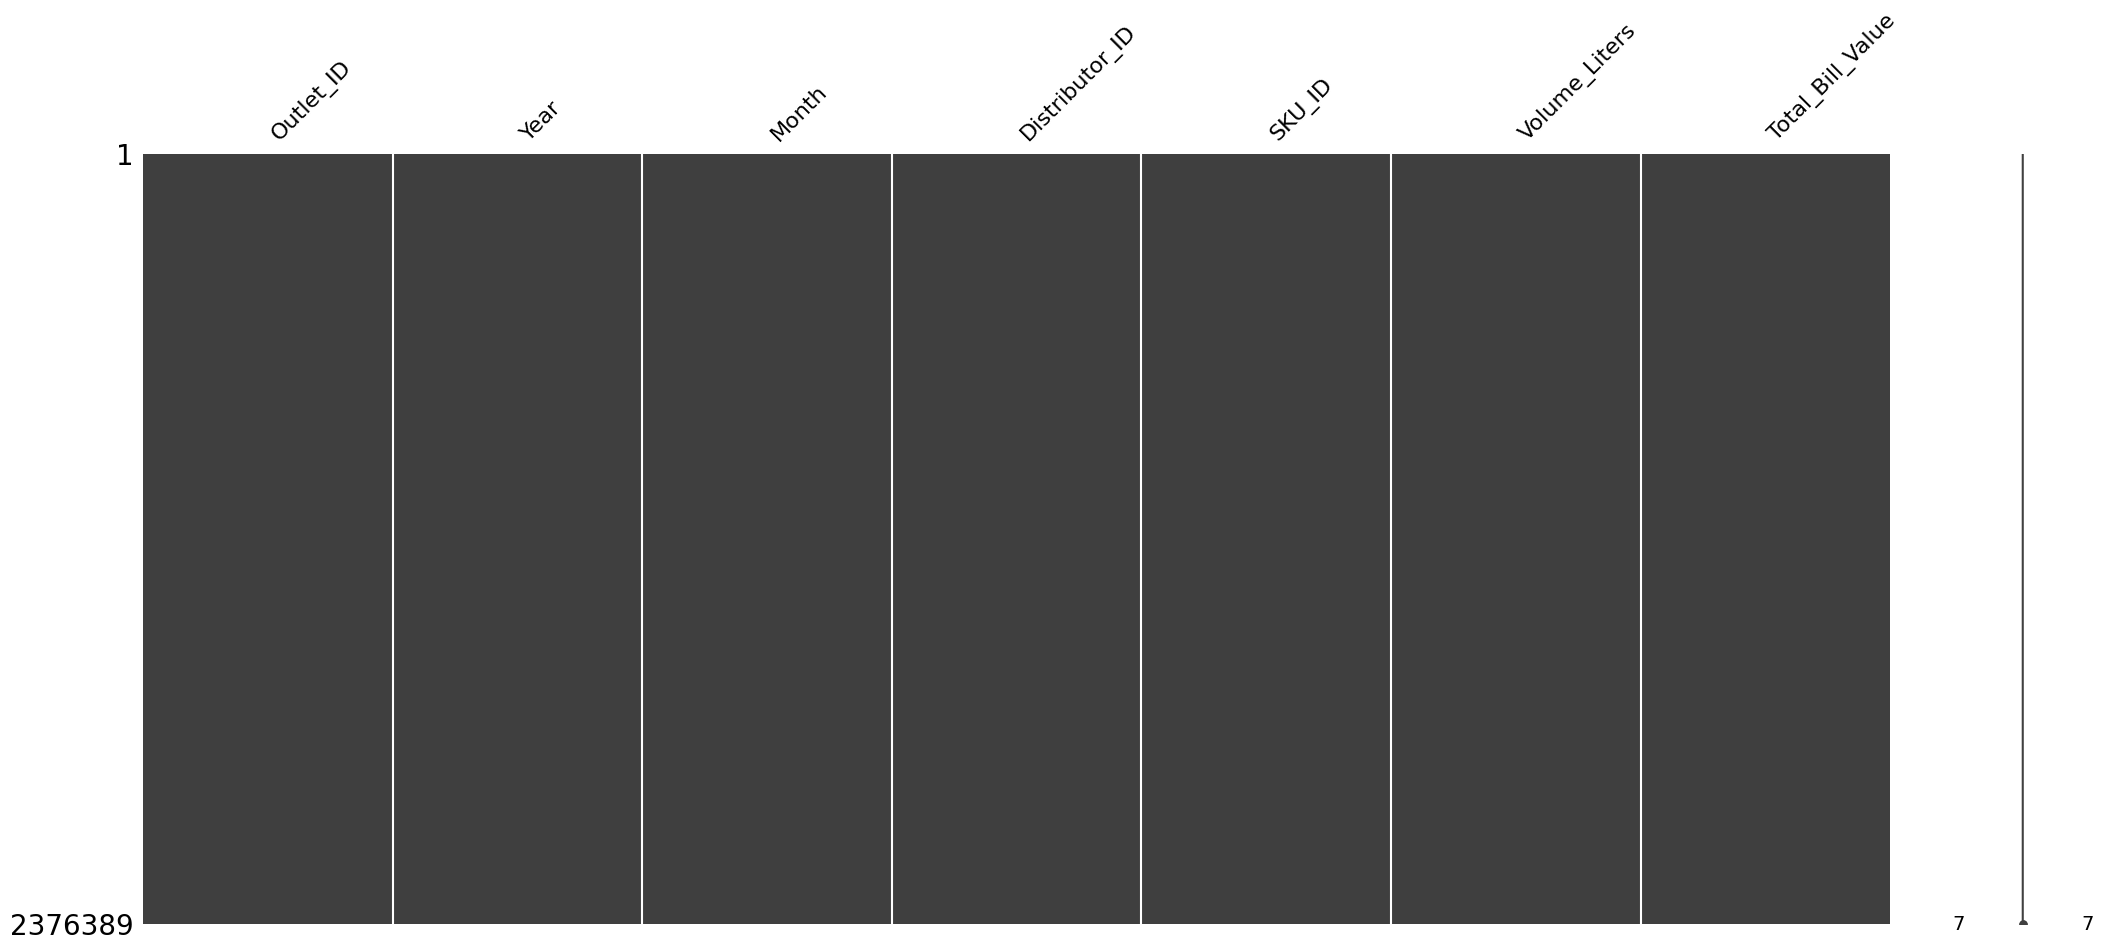

In [17]:
msno.matrix(transactions)
plt.show()

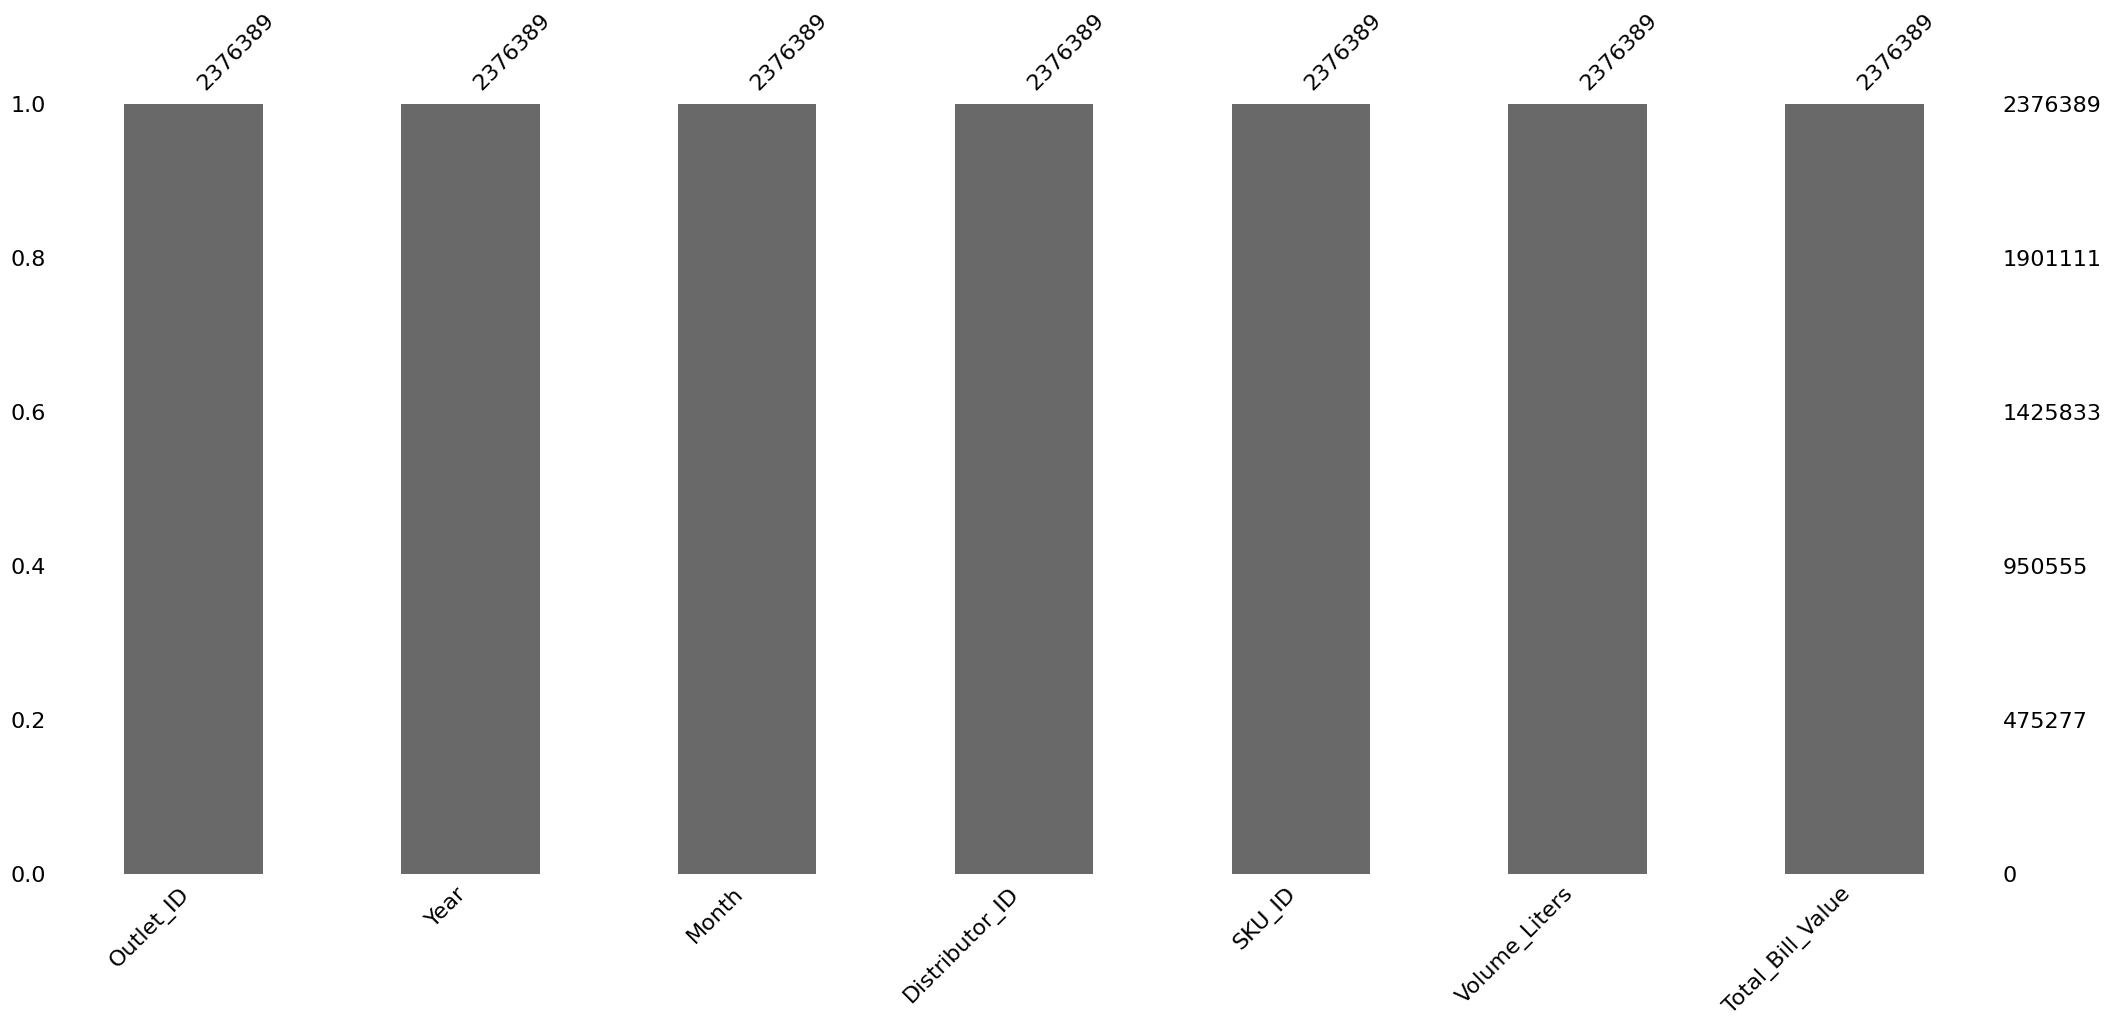

In [18]:
msno.bar(transactions)
plt.show()

In [23]:
transactions.duplicated().sum()

np.int64(0)

In [25]:
transactions.duplicated(
    subset=[
        'Outlet_ID',
        'Year',
        'Month',
        'Distributor_ID',
        'SKU_ID',
        'Volume_Liters',
        'Total_Bill_Value'
    ]
).sum()

np.int64(0)

In [26]:
dups = transactions[
    transactions.duplicated(
        subset=[
            'Outlet_ID',
            'Year',
            'Month',
            'Distributor_ID',
            'SKU_ID',
            'Volume_Liters',
            'Total_Bill_Value'
        ],
        keep=False
    )
]

print(dups.shape)
dups.head(20)

(0, 7)


,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value


In [28]:
transactions['Volume_Liters'].describe()

,Volume_Liters
count,2.376389e+06
mean,5.262422e+01
std,9.548678e+01
min,-9.564408e+02
25%,1.018487e+01
50%,2.315845e+01
75%,5.443157e+01
max,9.438578e+03


In [29]:
transactions['Total_Bill_Value'].describe()

,Total_Bill_Value
count,2.376389e+06
mean,1.379062e+04
std,1.644881e+04
min,-1.411536e+05
25%,3.527437e+03
50%,8.060190e+03
75%,1.629443e+04
max,1.528457e+05


In [34]:
negative_volume = transactions[
    transactions['Volume_Liters'] < 0
]

negative_volume.head()

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
234,OUT_19987,2024,12,DIST_S_02,SKU_07,-20.975223,-13633.905373
1097,OUT_14664,2025,4,DIST_NW_01,SKU_02,-142.662371,-36141.107438
1209,OUT_13596,2023,6,DIST_NW_02,SKU_05,-72.336385,-6510.268246
2278,OUT_10231,2025,2,DIST_C_03,SKU_05,-64.165540,-5774.896514
3621,OUT_17901,2024,7,DIST_S_01,SKU_08,-6.006375,-2642.768002


In [33]:
zero_volume = transactions[
    transactions['Volume_Liters'] == 0
]

zero_volume.head()

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
54272,OUT_00751,2025,12,DIST_W_01,SKU_01,0.0,143.938566
63653,OUT_08869,2023,5,DIST_W_03,SKU_10,0.0,133.001814
158444,OUT_09908,2023,1,DIST_C_02,SKU_09,0.0,93.915370
164047,OUT_18168,2024,7,DIST_S_02,SKU_01,0.0,82.598544
196039,OUT_16423,2025,10,DIST_NW_02,SKU_06,0.0,184.199724


In [36]:
transactions['Revenue_Per_Liter'] = (
    transactions['Total_Bill_Value'] /
    transactions['Volume_Liters']
)

In [37]:
transactions['Revenue_Per_Liter'].describe()

,Revenue_Per_Liter
count,2.376389e+06
mean,inf
std,NaN
min,8.400000e+00
25%,2.533333e+02
50%,3.250174e+02
75%,4.400000e+02
max,inf


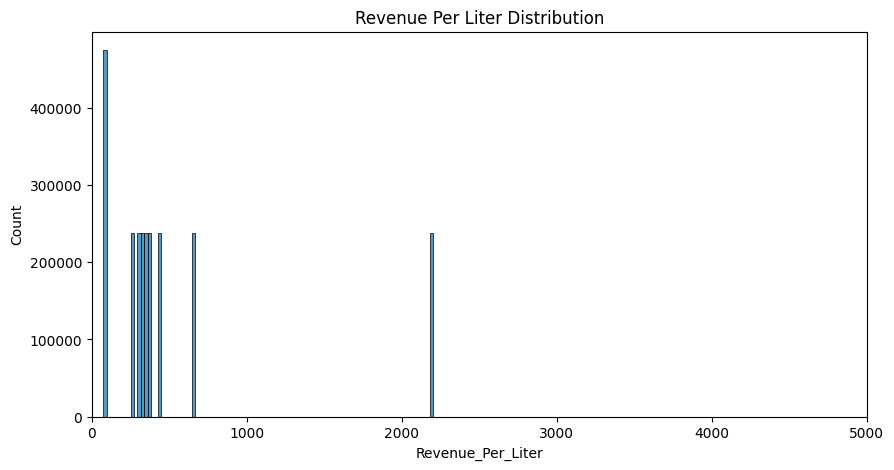

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    transactions['Revenue_Per_Liter'],
    bins=100
)

plt.xlim(0, 5000)
plt.title('Revenue Per Liter Distribution')
plt.show()

In [39]:
transactions['SKU_ID'].nunique()

10

In [40]:
transactions['SKU_ID'].value_counts().head(20)

,count
SKU_ID,
SKU_01,287644
SKU_07,232648
SKU_10,232336
SKU_04,232247
SKU_06,232066
SKU_03,232005
SKU_02,231963
SKU_05,231867
SKU_08,231828


In [41]:
outlet_txn_counts = (
    transactions.groupby('Outlet_ID')
    .size()
    .sort_values(ascending=False)
)

outlet_txn_counts.head()

,0
Outlet_ID,
OUT_11497,367
OUT_06356,367
OUT_06981,366
OUT_11251,365
OUT_12492,365


In [43]:
monthly_volume = (
    transactions.groupby([
        'Outlet_ID',
        'Year',
        'Month'
    ])['Volume_Liters']
    .sum()
    .reset_index()
)

monthly_volume.head()

,Outlet_ID,Year,Month,Volume_Liters
0,OUT_00001,2023,3,1390.918670
1,OUT_00001,2023,6,382.687950
2,OUT_00001,2023,8,552.713934
3,OUT_00001,2023,10,541.861465
4,OUT_00001,2023,11,223.594015


In [45]:
monthly_volume.groupby('Outlet_ID')['Volume_Liters'].agg([
    'mean',
    'std',
    'max'
]).head()

,mean,std,max
Outlet_ID,,,
OUT_00001,654.002607,420.769084,1941.470001
OUT_00002,644.768212,358.965826,1668.419807
OUT_00003,567.129126,387.019272,1790.851726
OUT_00004,640.424102,348.086771,1682.090300
OUT_00005,610.711386,362.927254,1815.720797


In [46]:
outlet_master['Outlet_Type'].value_counts()

,count
Outlet_Type,
Hotel,2797
Grocery,2768
SMMT,2723
Kiosk,2691
Pharmacy,2691
Bakery,2678
Eatery,2667
Bakry,395
Grocry,390


In [47]:
outlet_master['Outlet_Size'].value_counts(dropna=False)

,count
Outlet_Size,
Small,9672
Medium,5702
Large,2887
Extra Large,943
small,600
NaN,196


In [48]:
outlet_master['Cooler_Count'].describe()

,Cooler_Count
count,20000.000000
mean,1.291000
std,1.375505
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


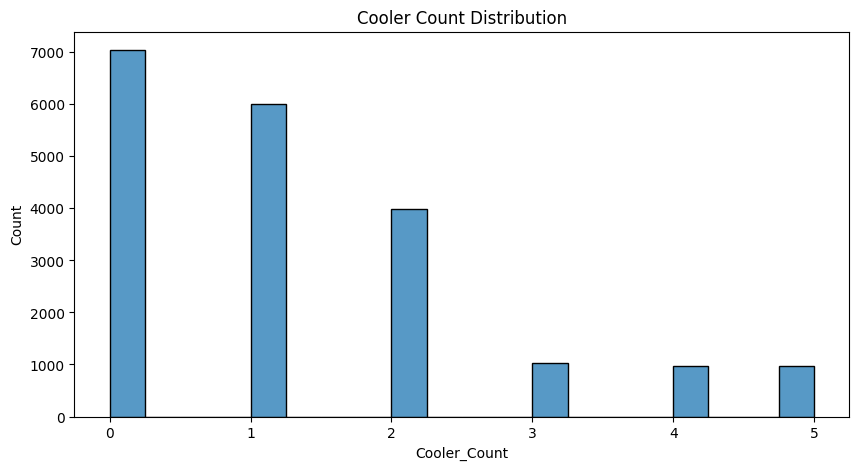

In [49]:
plt.figure(figsize=(10,5))

sns.histplot(
    outlet_master['Cooler_Count'],
    bins=20
)

plt.title('Cooler Count Distribution')
plt.show()

In [50]:
outlet_coordinates.isnull().sum()

,0
Outlet_ID,0
Latitude,0
Longitude,0


In [51]:
outlet_coordinates[['Latitude', 'Longitude']].describe()

,Latitude,Longitude
count,20000.000000,20000.000000
mean,7.739852,79.285245
std,7.303732,8.103265
min,0.000000,0.000000
25%,6.811049,79.925880
50%,7.022154,80.058188
75%,7.350576,80.456441
max,80.792317,80.799952


In [52]:
invalid_coords = outlet_coordinates[
    (
        (outlet_coordinates['Latitude'] < 5.5) |
        (outlet_coordinates['Latitude'] > 10)
    ) |
    (
        (outlet_coordinates['Longitude'] < 79) |
        (outlet_coordinates['Longitude'] > 82)
    )
]

invalid_coords.head()

,Outlet_ID,Latitude,Longitude
29,OUT_00030,79.923311,7.188307
89,OUT_00090,0.000000,0.000000
170,OUT_00171,79.999061,6.706547
251,OUT_00252,80.032979,7.134312
456,OUT_00457,80.008335,6.712571


In [53]:
seasonality.head()

,Distributor_ID,Year,Month,Seasonality_Index
0,DIST_W_01,2023,1,Moderate
1,DIST_W_01,2023,2,Moderate
2,DIST_W_01,2023,3,Moderate
3,DIST_W_01,2023,4,Favorable
4,DIST_W_01,2023,5,Un-Favorable


In [54]:
seasonality['Seasonality_Index'].value_counts()

,count
Seasonality_Index,
Moderate,249
Favorable,81
Un-Favorable,30


In [55]:
seasonality.groupby(
    ['Distributor_ID', 'Month']
)['Seasonality_Index'].value_counts()

Distributor_ID  Month  Seasonality_Index
DIST_C_01       1      Moderate             3
                2      Moderate             3
                3      Moderate             3
                4      Favorable            3
                5      Moderate             3
                                           ..
DIST_W_03       8      Moderate             3
                9      Moderate             3
                10     Moderate             3
                11     Moderate             3
                12     Favorable            3
Name: count, Length: 120, dtype: int64

In [56]:
holidays['Date'] = pd.to_datetime(holidays['Date'])

In [57]:
holidays['Holiday_Type'].value_counts()

,count
Holiday_Type,
Bank,99
Public,98
Mercantile,93
Poya Day,59


In [58]:
holidays['Month'] = holidays['Date'].dt.month

holidays.groupby('Month').size()

,0
Month,
1,34
2,39
3,25
4,54
5,47
6,18
7,16
8,25
9,28


Check Outlet_ID Integrity

In [59]:
missing_outlets = set(transactions['Outlet_ID']) - set(outlet_master['Outlet_ID'])

len(missing_outlets)

0

In [60]:
missing_coords = set(transactions['Outlet_ID']) - set(outlet_coordinates['Outlet_ID'])

len(missing_coords)

0

In [61]:
set(transactions['Distributor_ID']) - set(seasonality['Distributor_ID'])

set()